In [1]:
import osmnx as ox
import geopandas as gpd
import pandas as pd
import numpy as np
from geopy.distance import geodesic
from scipy.spatial import cKDTree

df = pd.read_csv("/Users/EthanMcElhone/Downloads/property_data_with_coordinates.csv")

# Ensure Date column is datetime
df['Date'] = pd.to_datetime(df['Date'])
df['Year'] = df['Date'].dt.year

# Filter out rows with missing or UNKNOWN categorical features
df_clean = df[
    df['PropertyType'].notna() & (df['PropertyType'] != 'UNKNOWN') &
    df['NewBuildFlag'].notna() & (df['NewBuildFlag'] != 'UNKNOWN') &
    df['Tenure'].notna() & (df['Tenure'] != 'UNKNOWN')
].copy()


# Disable cache + log files (fixes read-only OSError)
ox.settings.use_cache = False
ox.settings.log_console = False

green_tags = {
    'leisure': ['park', 'garden', 'recreation_ground', 'common', 'nature_reserve'],
    'landuse': ['grass', 'recreation_ground', 'forest'],
    'boundary': ['national_park']
}

print("Downloading parks and green spaces for London...")
green_spaces = ox.features_from_place('London, UK', tags=green_tags)


green_coords = []

for _, row in green_spaces.iterrows():
    geom = row.geometry

    if geom.geom_type == 'Point':
        green_coords.append([geom.y, geom.x])

    elif geom.geom_type in ['Polygon', 'MultiPolygon']:
        centroid = geom.centroid
        green_coords.append([centroid.y, centroid.x])

green_coords = np.array(green_coords)
print(f"Collected {len(green_coords)} green space locations.")


print("Building spatial index for green spaces...")
green_tree = cKDTree(green_coords)

valid_mask = df_clean['lat'].notna() & df_clean['long'].notna()
property_coords = df_clean.loc[valid_mask, ['lat', 'long']].values

print(f"Calculating green space proximity index for {len(property_coords)} properties...")

radius_km = 2
radius_deg = radius_km / 111.0  # ~111 km per degree approximation

indices_list = green_tree.query_ball_point(property_coords, radius_deg)

green_indices = np.zeros(len(df_clean))

for i, (prop_idx, nearby_indices) in enumerate(zip(valid_mask[valid_mask].index, indices_list)):
    if len(nearby_indices) == 0:
        continue
    
    prop_lat, prop_lon = property_coords[i]
    index_value = 0
    
    for gc_idx in nearby_indices:
        park_lat, park_lon = green_coords[gc_idx]
        distance = geodesic((prop_lat, prop_lon), (park_lat, park_lon)).km
        
        if distance <= radius_km:
            weight = (radius_km - distance) / radius_km
            index_value += weight
    
    green_indices[prop_idx] = index_value

df_clean['green_space_proximity_index'] = green_indices

print("Green space proximity index calculated!")
print(f"Mean index: {df_clean['green_space_proximity_index'].mean():.2f}")
print(f"Max index: {df_clean['green_space_proximity_index'].max():.2f}")

train_data = df_clean[df_clean['Year'].isin([2022, 2023])].copy()
predict_data = df_clean[df_clean['Year'] == 2024].copy()


Collected 205 green space locations.
Building spatial index for green spaces...
Calculating green space proximity index for 316250 properties...
Green space proximity index calculated!
Mean index: 0.98
Max index: 137.26



LINEAR REGRESSION MODELS BY PROPERTY TYPE
Using Green Space Proximity Index (2022-2023) to Predict 2024 Prices

--- Property Type: D ---
  Training samples: 9131
  Prediction samples: 4278
  Training R²: 0.0011
  Training RMSE: £2,063,126.49
  Intercept: £1,392,313.11
  Green Space Proximity coefficient: £38,354.54 per index unit
  Green Space Proximity p-value: 0.074611 

--- Property Type: F ---
  Training samples: 116047
  Prediction samples: 50177
  Training R²: 0.0131
  Training RMSE: £969,416.53
  Intercept: £895,044.11
  Green Space Proximity coefficient: £5,778.86 per index unit
  Green Space Proximity p-value: 0.000000 ***

--- Property Type: O ---
  Training samples: 11967
  Prediction samples: 5094
  Training R²: 0.0177
  Training RMSE: £12,261,818.91
  Intercept: £3,319,444.62
  Green Space Proximity coefficient: £112,068.84 per index unit
  Green Space Proximity p-value: 0.000000 ***

--- Property Type: S ---
  Training samples: 27466
  Prediction samples: 13748
  Trainin

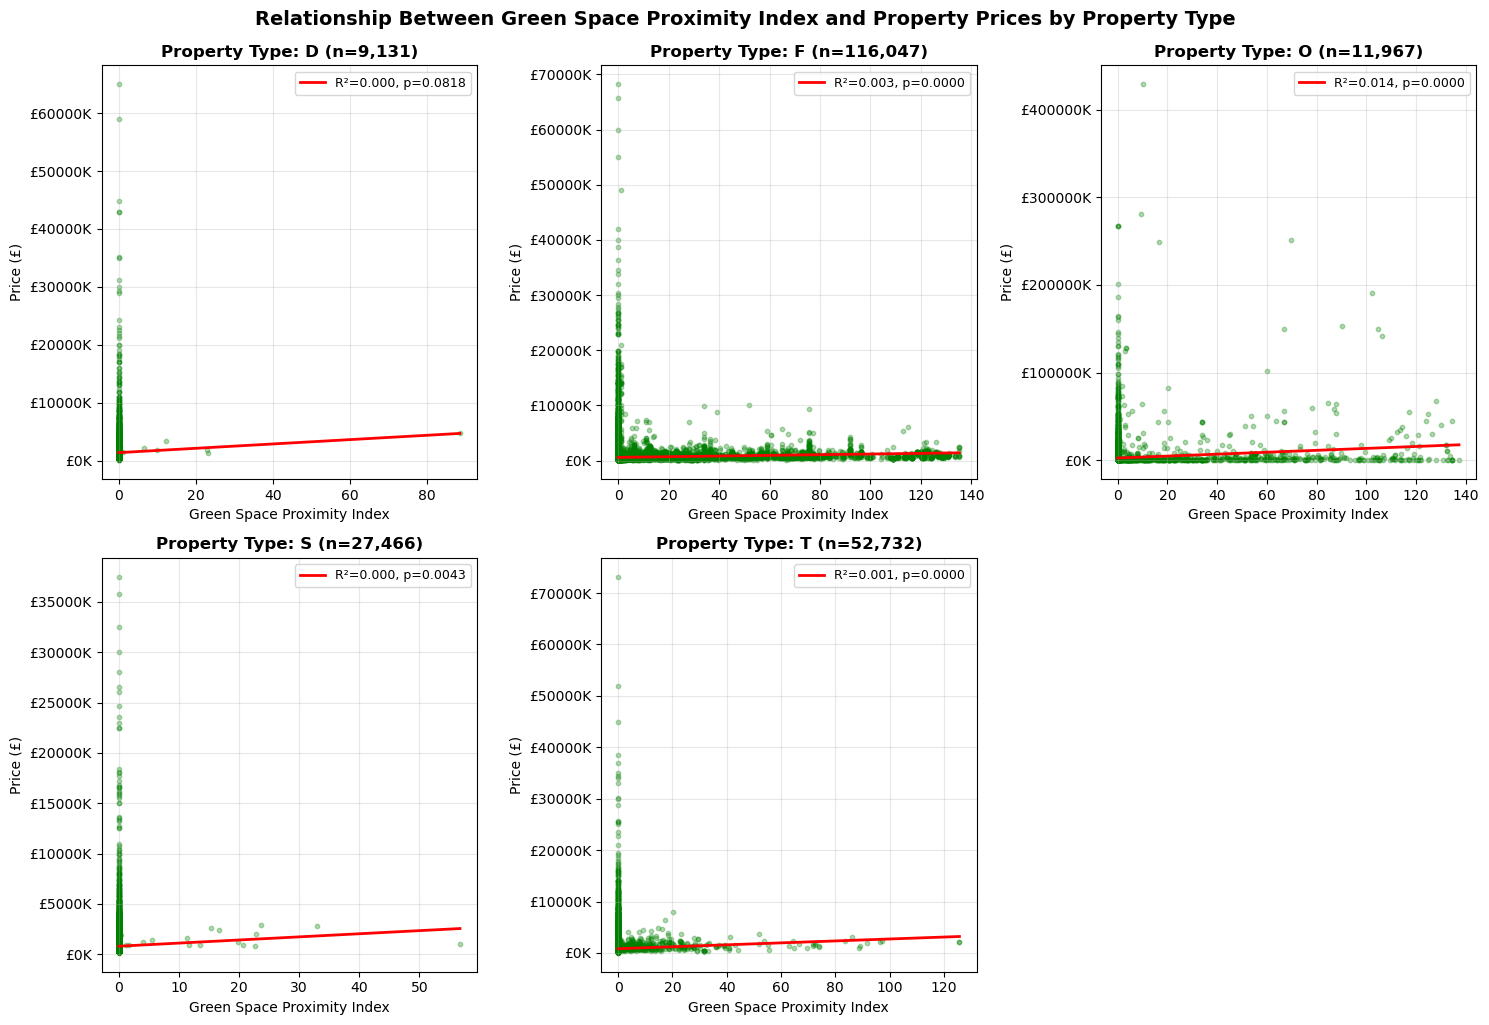

In [2]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import r2_score, mean_squared_error
import statsmodels.api as sm
import matplotlib.pyplot as plt
from scipy import stats
import numpy as np

print("\n" + "="*70)
print("LINEAR REGRESSION MODELS BY PROPERTY TYPE")
print("Using Green Space Proximity Index (2022-2023) to Predict 2024 Prices")
print("="*70)

# Features for this analysis
feature_cols_by_type = ['green_space_proximity_index', 'NewBuildFlag', 'Tenure']

# Dictionaries to store models and results
property_type_models = {}
property_type_results = {}

for prop_type in sorted(train_data['PropertyType'].unique()):
    print(f"\n--- Property Type: {prop_type} ---")
    
    # Filter by property type
    train_data_type = train_data[train_data['PropertyType'] == prop_type].copy()
    predict_data_type = predict_data[predict_data['PropertyType'] == prop_type].copy()
    
    # Remove missing values
    train_data_type = train_data_type[
        train_data_type['green_space_proximity_index'].notna() &
        train_data_type['Price'].notna()
    ].copy()
    
    if len(train_data_type) == 0:
        print(f"  ⚠️  No training data for {prop_type}")
        continue
    
    print(f"  Training samples: {len(train_data_type)}")
    print(f"  Prediction samples: {len(predict_data_type)}")
    
    # Prepare features and target
    X_train_type_raw = train_data_type[feature_cols_by_type].copy()
    y_train_type = train_data_type['Price'].values
    
    # Preprocessor
    preprocessor_type = ColumnTransformer(
        transformers=[
            ('num', 'passthrough', [0]),  # green_space_proximity_index
            ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), [1, 2])  # NewBuildFlag, Tenure
        ],
        remainder='drop'
    )
    
    X_train_type = preprocessor_type.fit_transform(X_train_type_raw)
    
    # Fit Linear Regression
    model_type = LinearRegression()
    model_type.fit(X_train_type, y_train_type)
    
    # Statsmodels for p-values
    X_train_type_sm = sm.add_constant(X_train_type)
    model_sm = sm.OLS(y_train_type, X_train_type_sm).fit()
    green_space_pvalue = model_sm.pvalues[1]  # first coefficient after intercept
    
    # Training metrics
    y_train_pred_type = model_type.predict(X_train_type)
    train_r2_type = r2_score(y_train_type, y_train_pred_type)
    train_rmse_type = np.sqrt(mean_squared_error(y_train_type, y_train_pred_type))
    
    print(f"  Training R²: {train_r2_type:.4f}")
    print(f"  Training RMSE: £{train_rmse_type:,.2f}")
    print(f"  Intercept: £{model_type.intercept_:,.2f}")
    print(f"  Green Space Proximity coefficient: £{model_type.coef_[0]:,.2f} per index unit")
    print(f"  Green Space Proximity p-value: {green_space_pvalue:.6f} {'***' if green_space_pvalue < 0.001 else '**' if green_space_pvalue < 0.01 else '*' if green_space_pvalue < 0.05 else ''}")
    
    # Predictions for 2024
    if len(predict_data_type) > 0:
        predict_data_type_valid = predict_data_type[
            predict_data_type['green_space_proximity_index'].notna()
        ].copy()
        
        if len(predict_data_type_valid) > 0:
            X_predict_type = preprocessor_type.transform(predict_data_type_valid[feature_cols_by_type])
            y_predict_type = model_type.predict(X_predict_type)
            predict_data_type_valid['Predicted_Price'] = y_predict_type
            predict_data_type = predict_data_type_valid
    
    # Store models & results
    property_type_models[prop_type] = {
        'model': model_type,
        'preprocessor': preprocessor_type,
        'train_data': train_data_type,
        'predict_data': predict_data_type
    }
    
    property_type_results[prop_type] = {
        'train_r2': train_r2_type,
        'train_rmse': train_rmse_type,
        'n_train': len(train_data_type),
        'intercept': model_type.intercept_,
        'green_space_coef': model_type.coef_[0],
        'green_space_pvalue': green_space_pvalue
    }

property_types = sorted(train_data['PropertyType'].unique())
n_types = len(property_types)
n_cols = 3
n_rows = (n_types + n_cols - 1)//n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5*n_rows))
axes = axes.flatten() if n_types > 1 else [axes]

for idx, prop_type in enumerate(property_types):
    ax = axes[idx]
    data_type = train_data[
        (train_data['PropertyType']==prop_type) &
        (train_data['green_space_proximity_index'].notna()) &
        (train_data['Price'].notna())
    ].copy()
    
    if len(data_type) == 0:
        ax.text(0.5, 0.5, f'No data for {prop_type}', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(f'Property Type: {prop_type}')
        continue
    
    ax.scatter(data_type['green_space_proximity_index'], data_type['Price'], alpha=0.3, s=10, color='green')
    
    # Linear trend line
    x = data_type['green_space_proximity_index'].values
    y = data_type['Price'].values
    slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
    x_line = np.linspace(x.min(), x.max(), 100)
    y_line = slope * x_line + intercept
    ax.plot(x_line, y_line, 'r-', linewidth=2, label=f'R²={r_value**2:.3f}, p={p_value:.4f}')
    
    ax.set_xlabel('Green Space Proximity Index')
    ax.set_ylabel('Price (£)')
    ax.set_title(f'Property Type: {prop_type} (n={len(data_type):,})', fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'£{x/1000:.0f}K'))

for idx in range(n_types, len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.suptitle('Relationship Between Green Space Proximity Index and Property Prices by Property Type',
             fontsize=14, fontweight='bold', y=1.02)
plt.show()


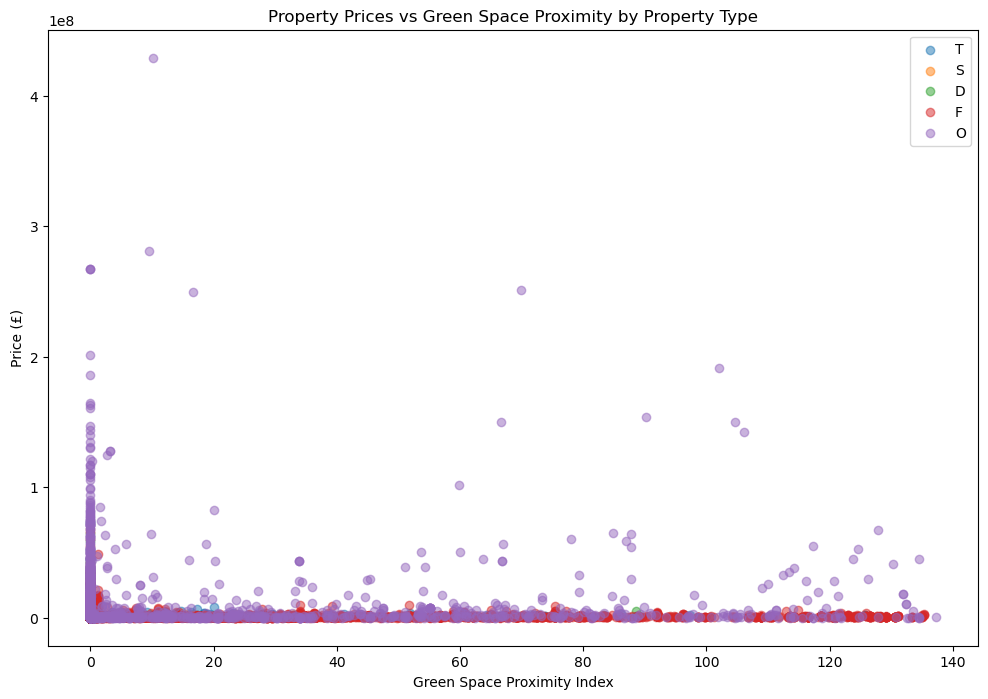

In [5]:
plt.figure(figsize=(12, 8))

for prop_type in train_data['PropertyType'].unique():
    prop_data = train_data[train_data['PropertyType'] == prop_type]
    plt.scatter(prop_data['green_space_proximity_index'], prop_data['Price'], alpha=0.5, label=prop_type)

plt.xlabel('Green Space Proximity Index')
plt.ylabel('Price (£)')
plt.legend()
plt.title('Property Prices vs Green Space Proximity by Property Type')
plt.show()